In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %% Imports
from jax import random, jit, numpy as jnp
from typing import Sequence
import jax

import matplotlib.pyplot as plt
from modax.data.burgers import burgers
from modax.training import mask_scheduler, create_stateful_update, Logger
from modax.layers import MaskedLeastSquares
from modax.feature_generators import library_backward
from modax.models.networks import MLP
from modax.losses.utils import mse
from modax.training.convergence import Convergence

from flax import optim, linen as nn
from flax.core import freeze
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
# %% Imports
from modax.data.kdv import DoubleSoliton
from modax.models import DeepmodBayes
from modax.linear_model.mask_estimator import ThresholdedLasso
from flax import optim

from modax.losses.utils import normal_LL, gamma_LL, precision

In [4]:
class CustomModel(nn.Module):
    """Simple feed-forward NN."""

    features: Sequence[int]

    @nn.compact
    def __call__(self, inputs):
        prediction, dt, theta = library_backward(MLP(self.features), inputs)
        coeffs = MaskedLeastSquares()((dt, theta))
        return prediction, dt, theta, coeffs

In [5]:
def custom_loss_fn(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )

    MSE = mse(prediction, y)
    Reg = mse(dt.squeeze(), (theta @ coeffs).squeeze())
    loss = MSE
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))


In [6]:
# %% Making data
key = random.PRNGKey(42)

x = jnp.linspace(-10, 10, 100)
t = jnp.linspace(0.1, 1.0, 10)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")

u = DoubleSoliton(x_grid, t_grid, c=[5.0, 2.0], x0=[0.0, -5.0])

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.2 * jnp.std(y) * random.normal(key, y.shape)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# %% Building model and params
model = CustomModel([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [11]:
update = create_stateful_update(custom_loss_fn, model=model, x=X_train, y=y_train)
validation_metric = jit(
    lambda opt, state: custom_loss_fn(opt.target, state, model, X_test, y_test)[1][1]
)
logger = Logger()
scheduler = mask_scheduler(delta=0.0, patience=1000)

In [12]:
# Training till mse
max_epochs = 1e4
for epoch in jnp.arange(max_epochs):
    (optimizer, state), train_metrics, output = update(optimizer, state)
    prediction, dt, theta, coeffs = output

    if epoch % 1000 == 0:
        print(f"Loss step {epoch}: {train_metrics['loss']}")

    if epoch % 25 == 0:
        val_metrics = validation_metric(optimizer, state)
        metrics = {
            **train_metrics,
            "val_mse": val_metrics["mse"],
            "val_reg": val_metrics["reg"],
        }
        logger.write(metrics, epoch)

        apply_sparsity, optimizer = scheduler(val_metrics["mse"], epoch, optimizer)

        if apply_sparsity:
            break
logger.close()


Loss step 0.0: 0.45289167761802673
Loss step 1000.0: 0.013875477015972137
Loss step 2000.0: 0.011748015880584717


In [13]:
variables = {"params": optimizer.target, **state}
prediction, _, _, coeffs = model.apply(variables, X, mutable=list(state.keys()))[0]
prediction = prediction.reshape(x_grid.shape)

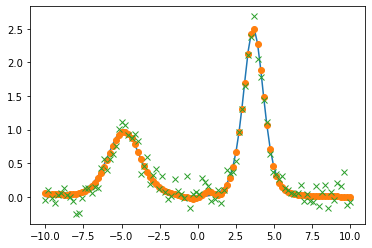

In [14]:
frame = 5
plt.plot(x, u[frame, :])
plt.plot(x, prediction[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [15]:
coeffs

DeviceArray([[-0.01786438],
             [-2.605364  ],
             [-0.07953341],
             [-0.17694   ],
             [ 0.08630278],
             [-2.989005  ],
             [ 0.28776193],
             [ 0.14463298],
             [-0.00860465],
             [ 0.85730237],
             [-0.09700248],
             [-0.02887784]], dtype=float32)

In [16]:
jnp.corrcoef(jnp.concatenate([y, prediction.reshape(-1, 1)], axis=1).T)

DeviceArray([[0.9999999, 0.980144 ],
             [0.980144 , 0.9999999]], dtype=float32)

Okay so that's not a bad idea, lets try it with a pinn

In [17]:
def loss_fn_pinn(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )

    MSE = mse(prediction, y)
    Reg = mse(dt.squeeze(), (theta @ coeffs).squeeze())
    loss = MSE + Reg
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [28]:
def loss_fn_pinn_scaled(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    
    MSE = mse(prediction, y)
    s = jax.nn.relu(jnp.corrcoef(jnp.concatenate([y, prediction], axis=1).T)[0, 1])
    
    Reg = mse(dt.squeeze(), (theta @ coeffs).squeeze())
    loss = MSE + s * Reg
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs, "s": s}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [19]:
# %% Building model and params
model = CustomModel([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [20]:
# baseline pinn
update = create_stateful_update(loss_fn_pinn, model=model, x=X_train, y=y_train)
validation_metric = jit(
    lambda opt, state: custom_loss_fn(opt.target, state, model, X_test, y_test)[1][1]
)
logger = Logger()
scheduler = mask_scheduler(delta=0.0, patience=1000)

In [21]:
# Training till mse
max_epochs = 1e4
for epoch in jnp.arange(max_epochs):
    (optimizer, state), train_metrics, output = update(optimizer, state)
    prediction, dt, theta, coeffs = output

    if epoch % 1000 == 0:
        print(f"Loss step {epoch}: {train_metrics['loss']}")

    if epoch % 25 == 0:
        val_metrics = validation_metric(optimizer, state)
        metrics = {
            **train_metrics,
            "val_mse": val_metrics["mse"],
            "val_reg": val_metrics["reg"],
        }
        logger.write(metrics, epoch)

        apply_sparsity, optimizer = scheduler(val_metrics["mse"], epoch, optimizer)

        if apply_sparsity:
            break
logger.close()


Loss step 0.0: 0.45382463932037354
Loss step 1000.0: 0.024117061868309975
Loss step 2000.0: 0.013421986252069473


In [22]:
variables = {"params": optimizer.target, **state}
prediction, _, _, coeffs = model.apply(variables, X, mutable=list(state.keys()))[0]
prediction = prediction.reshape(x_grid.shape)

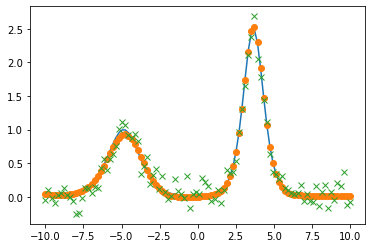

In [23]:
frame = 5
plt.plot(x, u[frame, :])
plt.plot(x, prediction[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [29]:
# %% Building model and params
model = CustomModel([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [30]:
# baseline pinn
update = create_stateful_update(loss_fn_pinn_scaled, model=model, x=X_train, y=y_train)
validation_metric = jit(
    lambda opt, state: custom_loss_fn(opt.target, state, model, X_test, y_test)[1][1]
)
logger = Logger()
scheduler = mask_scheduler(delta=0.0, patience=1000)

In [31]:
# Training till mse
max_epochs = 1e4
for epoch in jnp.arange(max_epochs):
    (optimizer, state), train_metrics, output = update(optimizer, state)
    prediction, dt, theta, coeffs = output

    if epoch % 1000 == 0:
        print(f"Loss step {epoch}: {train_metrics['loss']}")

    if epoch % 25 == 0:
        val_metrics = validation_metric(optimizer, state)
        metrics = {
            **train_metrics,
            "val_mse": val_metrics["mse"],
            "val_reg": val_metrics["reg"],
        }
        logger.write(metrics, epoch)

        apply_sparsity, optimizer = scheduler(val_metrics["mse"], epoch, optimizer)

        if apply_sparsity:
            break
logger.close()


Loss step 0.0: 0.45289167761802673
Loss step 1000.0: 0.014834482222795486
Loss step 2000.0: 0.01342059951275587


In [34]:
def loss_fn_pinn_bayes_typeII(
    params, state, model, x, y, prior_params_reg, prior_params_mse=(0.0, 0.0)
):

    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )

    # Calculating precision of mse
    tau = precision(y, prediction, *prior_params_mse)
    p_mse, MSE = normal_LL(prediction, y, tau)
    p_mse += gamma_LL(tau, *prior_params_mse)  # adding prior

    # Calculating precision of reg
    nu = precision(
        dt, theta @ coeffs, *prior_params_reg
    )  # calculates nu given gamma prior
    p_reg, reg = normal_LL(dt, theta @ coeffs, nu)
    p_reg += gamma_LL(nu, *prior_params_reg)  # adding priorr

    loss = -(p_mse + p_reg)

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": coeffs,
        "tau": tau,
        "nu": nu,
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [35]:
# %% Building model and params
model = CustomModel([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [46]:
# baseline pinn
update = create_stateful_update(loss_fn_pinn_bayes_typeII, model=model, x=X_train, y=y_train, prior_params_reg = (X_train.shape[0] / 2, X_train.shape[0] / 2 * 1e-6))
validation_metric = jit(
    lambda opt, state: custom_loss_fn(opt.target, state, model, X_test, y_test)[1][1]
)
logger = Logger()
scheduler = mask_scheduler(delta=0.0, patience=1e9)

In [47]:
# Training till mse
max_epochs = 5000
for epoch in jnp.arange(max_epochs):
    (optimizer, state), train_metrics, output = update(optimizer, state)
    prediction, dt, theta, coeffs = output

    if epoch % 1000 == 0:
        print(f"Loss step {epoch}: {train_metrics['loss']}")

    if epoch % 25 == 0:
        val_metrics = validation_metric(optimizer, state)
        metrics = {
            **train_metrics,
            "val_mse": val_metrics["mse"],
            "val_reg": val_metrics["reg"],
        }
        logger.write(metrics, epoch)

        apply_sparsity, optimizer = scheduler(val_metrics["mse"], epoch, optimizer)

        if apply_sparsity:
            break
logger.close()


Loss step 0: -10349.6669921875
Loss step 1000: -9805.6962890625
Loss step 2000: -10543.794921875
Loss step 3000: -10430.908203125
Loss step 4000: -9857.701171875


In [111]:
def loss_fn_pinn_bayesian_mse(
    params, state, model, x, y, prior_params_reg, prior_params_mse=(0.0, 0.0)
):

    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )

    # Calculating precision of mse
    tau = precision(y, prediction, *prior_params_mse)
    p_mse, MSE = normal_LL(prediction, y, tau)
    p_mse += gamma_LL(tau, *prior_params_mse)  # adding prior

    # Calculating precision of reg
    nu = precision(
        dt, theta @ coeffs, *prior_params_reg
    )  # calculates nu given gamma prior
    p_reg, reg = normal_LL(dt, theta @ coeffs, nu)
    p_reg += gamma_LL(nu, *prior_params_reg)  # adding priorr

    loss = -(p_mse)

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": coeffs,
        "tau": tau,
        "nu": nu,
        "normed_coeffs": coeffs * jnp.linalg.norm(theta, axis=0)[:, None],
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [112]:
# %% Building model and params
model = CustomModel([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [113]:
# baseline pinn
update = create_stateful_update(loss_fn_pinn_bayesian_mse, model=model, x=X_train, y=y_train, prior_params_reg = (X_train.shape[0] / 2, X_train.shape[0] / 2 * 1e-6))
validation_metric = jit(
    lambda opt, state: custom_loss_fn(opt.target, state, model, X_test, y_test)[1][1]
)
logger = Logger()
scheduler = mask_scheduler(delta=0.0, patience=1000)

In [114]:
# Training till mse
max_epochs = 1e4
for epoch in jnp.arange(max_epochs):
    (optimizer, state), train_metrics, output = update(optimizer, state)
    prediction, dt, theta, coeffs = output

    if epoch % 1000 == 0:
        print(f"Loss step {epoch}: {train_metrics['loss']}")

    if epoch % 25 == 0:
        val_metrics = validation_metric(optimizer, state)
        metrics = {
            **train_metrics,
            "val_mse": val_metrics["mse"],
            "val_reg": val_metrics["reg"],
        }
        logger.write(metrics, epoch)

        apply_sparsity, optimizer = scheduler(val_metrics["mse"], epoch, optimizer)

        if apply_sparsity:
            break
logger.close()


Loss step 0.0: 819.1007080078125
Loss step 1000.0: -603.9898071289062
Loss step 2000.0: -642.319091796875


In [214]:
def loss_fn_pinn_bayes_typeII_scaled(
    params, state, model, x, y, prior_params_reg, prior_params_mse=(0.0, 0.0)
):

    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )

    # Calculating precision of mse
    tau = precision(y, prediction, *prior_params_mse)
    p_mse, MSE = normal_LL(prediction, y, tau)
    p_mse += gamma_LL(tau, *prior_params_mse)  # adding prior
    
    s = jax.nn.relu(jnp.corrcoef(jnp.concatenate([y, prediction], axis=1).T)[0, 1])
    
    # Calculating precision of reg
    T = 1e-1
    nu = precision(
        dt, theta @ coeffs, prior_params_reg[0], prior_params_reg[1] * jnp.exp(-(s - 1) / T)
    )  # calculates nu given gamma prior
    p_reg, reg = normal_LL(dt, theta @ coeffs, nu)
    p_reg += gamma_LL(nu, *prior_params_reg)  # adding priorr
    
    loss = -(p_mse + p_reg)

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": coeffs,
        "tau": tau,
        "nu": nu,
        "normed_coeffs": coeffs * jnp.linalg.norm(theta, axis=0)[:, None],
        "s": s
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [215]:
# %% Building model and params
model = CustomModel([30, 30, 30, 1])
variables = model.init(key, X)
[0]
optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [216]:
# baseline pinn
update = create_stateful_update(loss_fn_pinn_bayes_typeII_scaled, model=model, x=X_train, y=y_train, prior_params_reg = (X_train.shape[0] / 2, X_train.shape[0] / 2 * 1e-6))
validation_metric = jit(
    lambda opt, state: custom_loss_fn(opt.target, state, model, X_test, y_test)[1][1]
)
logger = Logger()
scheduler = mask_scheduler(delta=0.0, patience=15000)

In [217]:
# Training till mse
max_epochs = 1e4
for epoch in jnp.arange(max_epochs):
    (optimizer, state), train_metrics, output = update(optimizer, state)
    prediction, dt, theta, coeffs = output

    if epoch % 500 == 0:
        print(f"Loss step {epoch}: {train_metrics['loss']}")
        print(f"{train_metrics['s']}")
        print(jax.nn.relu(jnp.corrcoef(jnp.concatenate([y_train, prediction], axis=1).T)[0, 1]))
    if epoch % 25 == 0:
        val_metrics = validation_metric(optimizer, state)
        metrics = {
            **train_metrics,
            "val_mse": val_metrics["mse"],
            "val_reg": val_metrics["reg"],
        }
        logger.write(metrics, epoch)

        apply_sparsity, optimizer = scheduler(val_metrics["mse"], epoch, optimizer)

        if apply_sparsity:
            (optimizer, state), train_metrics, output = update(optimizer, state)
            prediction, dt, theta, coeffs = output
            print(jax.nn.relu(jnp.corrcoef(jnp.concatenate([y_train, prediction], axis=1).T)[0, 1]))
            break
logger.close()


Loss step 0.0: -1981.5189208984375
0.0
0.0
Loss step 500.0: -8324.6474609375
0.8127156496047974
0.8127159
Loss step 1000.0: -8823.728515625
0.8732157945632935
0.8732159
Loss step 1500.0: -9042.7373046875
0.9037042856216431
0.9037044
Loss step 2000.0: -9162.28125
0.9293265342712402
0.9293267
Loss step 2500.0: -9208.0283203125
0.932006299495697
0.9320063
Loss step 3000.0: -9177.2490234375
0.931562066078186
0.9315621
Loss step 3500.0: -9222.416015625
0.9340324997901917
0.93403256
Loss step 4000.0: -9180.4267578125
0.932048499584198
0.9320487
Loss step 4500.0: -9208.2939453125
0.9340102076530457
0.9340103
Loss step 5000.0: -9186.38671875
0.9320958256721497
0.932096
Loss step 5500.0: -9191.373046875
0.9340240359306335
0.9340241
Loss step 6000.0: -9203.4130859375
0.9349849820137024
0.9349849
Loss step 6500.0: -9197.1474609375
0.9349097013473511
0.9349098
Loss step 7000.0: -9199.240234375
0.9322266578674316
0.93222684
Loss step 7500.0: -9210.7685546875
0.9345144629478455
0.93451434
Loss step 

In [48]:
variables = {"params": optimizer.target, **state}
prediction, _, _, coeffs = model.apply(variables, X, mutable=list(state.keys()))[0]
prediction = prediction.reshape(x_grid.shape)

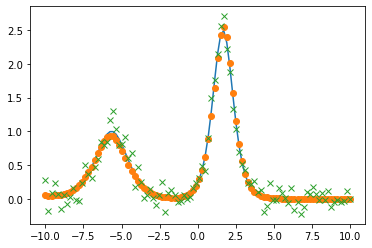

In [52]:
frame = 1
plt.plot(x, u[frame, :])
plt.plot(x, prediction[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [221]:
variables = {"params": optimizer.target, **state}
prediction, _, _, coeffs = model.apply(variables, X_train, mutable=list(state.keys()))[0]

In [222]:
jnp.corrcoef(jnp.concatenate([y_train, prediction], axis=1).T)

DeviceArray([[0.9999999 , 0.9374569 ],
             [0.93745685, 1.        ]], dtype=float32)

In [159]:
state

FrozenDict({
    vars: {
        MaskedLeastSquares_0: {
            mask: DeviceArray([ True,  True,  True,  True,  True,  True,  True,  True,
                          True,  True,  True,  True], dtype=bool),
        },
    },
})

In [ ]:
y_train - prediction

In [190]:
p = jnp.linspace(0, 1, 1e5)

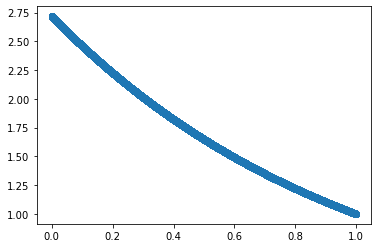

In [232]:
T = 1
plt.plot(p, jnp.exp(-(p-1) / T), 'o')

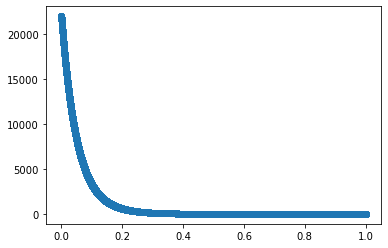

In [90]:
T = 1e-1
plt.plot(p, jnp.exp((p-1)**2 / T), 'o')

In [92]:
T = 1e-1
p=0.7
jnp.exp((p-1)**2 / T)

DeviceArray(1.105171, dtype=float32)